In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# 1. Load the dataset
df = pd.read_csv('Customer_Segmentation.csv')

# 2. Display basic info and first few rows
print(f"Dataset Shape: {df.shape}\n")
display(df.head())
print("\nDataset Info:")
df.info()

Dataset Shape: (2240, 1)



,ID\tYear_Birth\tEducation\tMarital_Status\tIncome\tKidhome\tTeenhome\tDt_Customer\tRecency\tMntWines\tMntFruits\tMntMeatProducts\tMntFishProducts\tMntSweetProducts\tMntGoldProds\tNumDealsPurchases\tNumWebPurchases\tNumCatalogPurchases\tNumStorePurchases\tNumWebVisitsMonth\tAcceptedCmp3\tAcceptedCmp4\tAcceptedCmp5\tAcceptedCmp1\tAcceptedCmp2\tComplain\tZ_CostContact\tZ_Revenue\tResponse
0,5524\t1957\tGraduation\tSingle\t58138\t0\t0\t0...
1,2174\t1954\tGraduation\tSingle\t46344\t1\t1\t0...
2,4141\t1965\tGraduation\tTogether\t71613\t0\t0\...
3,6182\t1984\tGraduation\tTogether\t26646\t1\t0\...
4,5324\t1981\tPhD\tMarried\t58293\t1\t0\t19-01-2...



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                                                                                                                                                                    Non-Null Count  Dtype
---  ------                                                                                                                                                                                                                                                                                                                                                                    --------------  -----
 0   ID	Year_Birth	Education	Marital_Status	Income	Kidhome	Teenhome	Dt_Customer	Recency	MntWines	MntFruits	MntMe

In [3]:
# 1. Load the dataset with tab separator
df = pd.read_csv('Customer_Segmentation.csv', sep='\t')

# 2. Display basic info and first few rows
print(f"Dataset Shape: {df.shape}\n")
display(df.head())
print("\nDataset Info:")
df.info()

Dataset Shape: (2240, 29)



,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null

In [7]:
# 1. Handle missing values
df_clean = df.dropna(subset=['Income']).copy()

# 2. Feature Engineering
# Calculate Age
df_clean['Age'] = 2026 - df_clean['Year_Birth']

# Calculate Total Spending across all categories
df_clean['total_Spent'] = (
    df_clean['MntWines'] +
    df_clean['MntFruits'] +
    df_clean['MntMeatProducts'] +
    df_clean['MntFishProducts'] +
    df_clean['MntSweetProducts'] +
    df_clean['MntGoldProds']
)

# Total Children in household
df_clean['Children'] = df_clean['Kidhome'] + df_clean['Teenhome']

# Filter extreme outliers
df_clean = df_clean[(df_clean['Age'] < 90) & (df_clean['Income'] < 200000)]

# Display engineered features
display(df_clean[['Age', 'Income', 'total_Spent', 'Children']].describe())

,Age,Income,total_Spent,Children
count,2212.000000,2212.000000,2212.000000,2212.000000
mean,57.086347,51958.810579,607.268083,0.947559
std,11.701599,21527.278844,602.513364,0.749466
min,30.000000,1730.000000,5.000000,0.000000
25%,49.000000,35233.500000,69.000000,0.000000
50%,56.000000,51371.000000,397.000000,1.000000
75%,67.000000,68487.000000,1048.000000,1.000000
max,86.000000,162397.000000,2525.000000,3.000000


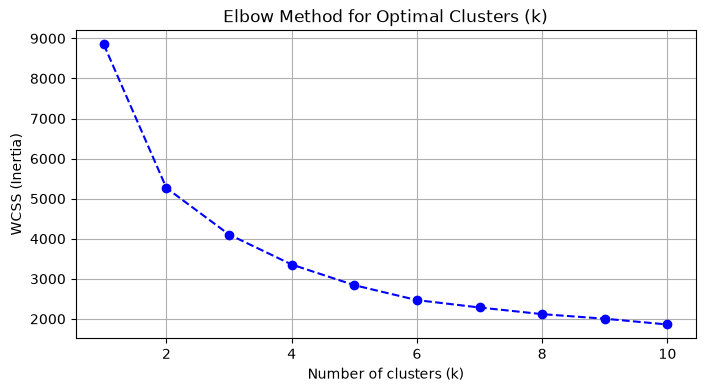

In [8]:
# 1. Select core clustering features
features = ['Age', 'Income', 'total_Spent', 'Children']
X = df_clean[features]

# 2. Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Calculate WCSS (Within-Cluster Sum of Squares) for k = 1 to 10
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# 4. Plot the Elbow curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal Clusters (k)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

In [10]:
# 1. Fit the final KMeans model with k=4
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)

# 2. inspect cluster profiles (mean values of core metrics)
cluster_summary = df_clean.groupby('Cluster')[['Age', 'Income', 'total_Spent', 'Children']].mean().round(1)
cluster_counts = df_clean['Cluster'].value_counts().rename('Customer_Count')

profile_table = cluster_summary.join(cluster_counts)
display(profile_table)

# 3. Save the trained scaler and model for deployment (e.g., Streamlit app)
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(kmeans, 'kmeans_model.pkl')
print("Model and scaler successfully saved as 'kmeans_model.pkl' and 'scaler.pkl'!")

,Age,Income,total_Spent,Children,Customer_Count
Cluster,,,,,
0,51.6,77068.8,1430.0,0.3,466
1,60.6,43560.6,209.1,2.1,444
2,49.2,32810.3,154.8,0.8,728
3,68.8,62355.4,821.2,0.7,574


Model and scaler successfully saved as 'kmeans_model.pkl' and 'scaler.pkl'!
